## Mini Project: MNIST Hnad-written Digits

(60000, 28, 28) (60000,)
uint8 uint8


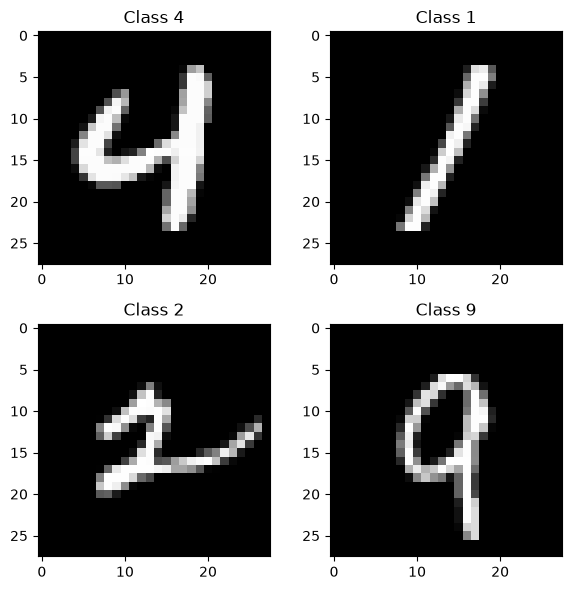

In [6]:
from keras.datasets import mnist
from keras.datasets import fashion_mnist
from keras.layers import Dense, Dropout, Input
from keras.models import Sequential
from sklearn.preprocessing import OneHotEncoder
from keras.losses import CategoricalCrossentropy
from keras.metrics import CategoricalAccuracy
from keras.optimizers import Adam, SGD
from matplotlib import pyplot as plt
import numpy as np
import random

(xtrain, ytrain), (xtest, ytest) = mnist.load_data()
print(xtrain.shape, ytrain.shape)
print(xtrain.dtype, ytrain.dtype)

plt.rcParams['figure.figsize'] = (6, 6)

for i in range(4):
    plt.subplot(2, 2, i + 1)
    num = random.randint(0, len(xtrain))
    plt.imshow(xtrain[num], cmap='gray', interpolation='none')
    plt.title("Class {}".format(ytrain[num]))

plt.tight_layout()

In [2]:
X_train = xtrain.reshape(xtrain.shape[0], xtrain.shape[1] * xtrain.shape[2])
X_test = xtest.reshape(xtest.shape[0], xtest.shape[1] * xtest.shape[2])

print(X_train.shape, X_test.shape)

(60000, 784) (10000, 784)


In [3]:
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

X_train /= 255
X_test /= 255

encoder = OneHotEncoder(sparse_output=False)
encoder.fit(ytrain.reshape(-1, 1))
print(encoder.categories_)

ytrain_encoded = encoder.transform(ytrain.reshape(-1, 1)).astype(np.float32)
ytest_encoded = encoder.transform(ytest.reshape(-1, 1)).astype(np.float32)

[array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)]


In [7]:
# build a CNN model
vector_shape = (X_train.shape[1],)
n_classes = 10
loss_function = CategoricalCrossentropy(from_logits=True)

cnn = Sequential([
    Input(shape=(784,)),
    Dense(12, activation='relu', input_shape=vector_shape, kernel_initializer='he_uniform'),
    Dense(8, activation='relu', kernel_initializer='he_uniform'),
    Dense(n_classes),
])

cnn.compile(
    loss=loss_function,
    optimizer=Adam(learning_rate=0.001),
    metrics=[CategoricalAccuracy(name='accuracy')]
)

cnn_model = cnn.fit(
    X_train, ytrain_encoded, epochs=25, batch_size=32, verbose=1, validation_split=0.2
)

c:\Users\LEI\Documents\deep-learning-ibm\.venv\Lib\site-packages\keras\src\layers\core\dense.py:102: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8087 - loss: 0.6359 - val_accuracy: 0.9072 - val_loss: 0.3128
Epoch 2/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9159 - loss: 0.2905 - val_accuracy: 0.9197 - val_loss: 0.2642
Epoch 3/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9270 - loss: 0.2502 - val_accuracy: 0.9287 - val_loss: 0.2451
Epoch 4/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9344 - loss: 0.2280 - val_accuracy: 0.9335 - val_loss: 0.2316
Epoch 5/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9388 - loss: 0.2131 - val_accuracy: 0.9373 - val_loss: 0.2219
Epoch 6/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9418 - loss: 0.2028 - val_accuracy: 0.9380 - val_loss: 0.2163
Epoch 7/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9442 - loss: 0.1946 - val_accuracy: 0.9396 - val_loss: 0.2124
Epoch 8/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9464 - loss: 0.1880 - 

In [16]:
test_acc = cnn.evaluate(X_test, ytest_encoded, verbose=1)
print(f"Test Results - Loss: {test_acc[0]:.3f} | Accuracy: {(test_acc[1] * 100):.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9447 - loss: 0.1997
Test Results - Loss: 0.200 | Accuracy: 94.47%
